In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#PARAMETROS
muy = 0.0
muz = 0.0
PY=[0,0]
PZ=[0,0]
vizY = [4,4]
vizZ = [12,12]
vizX = 4
hy = [1.2/vizY[0],1.2/vizY[1]]
hz = [1.0/vizZ[0],1.0/vizZ[1]]
hx = 0.5
dz = 0.2
dy = 0.15

In [3]:
#Transições Aproximação de Campo Médio

def P0Xcm(P0,PX):
    return P0*(1-(1-hx*PX)**vizX)

def PXYcm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[1]*PY[1]-hy[0]*PY[0])**vizY[0])

def PXY1cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (muy/2*(1-(1-PY[1]*hy[1])**vizY[1])+(1-muy/2)*(1-(1-PY[0]*hy[0])**vizY[0]))

def PXY2cm(PX,PY):
    return PX*(1-(1-hy[1]*PY[1])**(vizY[1]-vizY[0])*(1-hy[0]*PY[0]-hy[1]*PY[1])**vizY[0])/(2-(1-hy[0]*PY[0])**vizY[0]-(1-hy[1]*PY[1])**vizY[1]) * (muy/2*(1-(1-PY[0]*hy[0])**vizY[0])+(1-muy/2)*(1-(1-PY[1]*hy[1])**vizY[1]))

def PY1Zcm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])
    
def PY2Zcm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PZ[1]-hz[0]*PZ[0])**vizZ[0])

def PY1Z1cm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))
    
def PY2Z1cm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[1]*PZ[1])**vizZ[1])+(1-muz/2)*(1-(1-hz[0]*PZ[0])**vizZ[0]))

def PY1Z2cm(PY,PZ):
    return PY[0]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

def PY2Z2cm(PY,PZ):
    return PY[1]*(1-(1-hz[1]*PZ[1])**(vizZ[1]-vizZ[0])*(1-hz[0]*PZ[0]-hz[1]*PZ[1])**vizZ[0])/(2-(1-hz[0]*PZ[0])**vizZ[0]-(1-hz[1]*PZ[1])**vizZ[1]) * (muz/2*(1-(1-hz[0]*PZ[0])**vizZ[0])+(1-muz/2)*(1-(1-hz[1]*PZ[1])**vizZ[1]))

In [4]:
#Transições Aproximação de Pares

def PX0par(P0,PX0):
    return P0*(1-(1-hx*PX0/P0)**vizX)

def pX0par2(P0,PX0):
    return (1-(1-hx*PX0/P0)**(vizX-1))

#############################################

def PXYpar(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])

def PXYpar2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))

#############################################

def PXY1par(PX,PXY1,PXY2):
    return PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])
            +(1-(1-PXY2/PX)**vizY[1]))*(muy/2*(1-(1-PXY2/PX)**vizY[1])+(1-muy/2)*(1-(1-PXY1/PX)**vizY[0]))

def PXY1par2(PX,PXY1,PXY2): 
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY2/PX)**(vizY[1]-1))+(1-muy/2)*(1-(1-PXY1/PX)**(vizY[0]-1)))

#############################################

def PXY2par(PX,PXY1,PXY2): 
    return (PX*(1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**vizY[0])/((1-(1-PXY1/PX)**vizY[0])+(1-(1-PXY2/PX)**vizY[1]))
            *(muy/2*(1-(1-PXY1/PX)**vizY[0])+(1-muy/2)*(1-(1-PXY2/PX)**vizY[1])))

def PXY2par2(PX,PXY1,PXY2):
    return (1-(1-hy[1]*PXY2/PX)**(vizY[1]-vizY[0])*(1-hy[1]*PXY2/PX-hy[0]*PXY1/PX)**(vizY[0]-1))/((1-(1-PXY1/PX)**(vizY[0]-1))
            +(1-(1-PXY2/PX)**(vizY[1]-1)))*(muy/2*(1-(1-PXY1/PX)**(vizY[0]-1))+(1-muy/2)*(1-(1-PXY2/PX)**(vizY[1]-1)))

#############################################

def PY1Zpar(PY,PY1Z1,PY1Z2):
    return PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])

def PY1Zpar2(PY,PY1Z1,PY1Z2):
    return (1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))

#############################################

def PY2Zpar(PY,PY2Z1,PY2Z2):
    return PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])

def PY2Zpar2(PY,PY2Z1,PY2Z2):
    return (1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))

#############################################

def PY1Z1par(PY,PY1Z1,PY1Z2):
    return (PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])/((1-(1-PY1Z1/PY[0])**vizZ[0]+(1-(1-PY1Z2/PY[0])**vizZ[1])))
        * (muz/2*(1-(1-PY1Z2/PY[0])**vizZ[1])+(1-muz/2)*(1-(1-PY1Z1/PY[0])**vizZ[0])))

def PY1Z1par2(PY,PY1Z1,PY1Z2):
    return ((1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[0])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY1Z1/PY[0])**(vizZ[0]-1))))

#############################################

def PY1Z2par(PY,PY1Z1,PY1Z2):
    return (PY[0]*(1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**vizZ[0])/((1-(1-PY1Z1/PY[0])**vizZ[0]+(1-(1-PY1Z2/PY[0])**vizZ[1])))
        * (muz/2*(1-(1-PY1Z1/PY[0])**vizZ[0])+(1-muz/2)*(1-(1-PY1Z2/PY[0])**vizZ[1])))

def PY1Z2par2(PY,PY1Z1,PY1Z2):
    return ((1-(1-hz[1]*PY1Z2/PY[0])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY1Z2/PY[0]-hz[0]*PY1Z1/PY[0])**(vizZ[0]-1))/((1-(1-PY1Z1/PY[0])**(vizZ[0]-1)+(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY1Z1/PY[0])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY1Z2/PY[0])**(vizZ[1]-1))))

#############################################

def PY2Z1par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z2/PY[1])**vizZ[1])+(1-muz/2)*(1-(1-PY2Z1/PY[1])**vizZ[0])))

def PY2Z1par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
            * (muz/2*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))+(1-muz/2)*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))))

#############################################
def PY2Z2par(PY,PY2Z1,PY2Z2):
    return (PY[1]*(1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**vizZ[0])/((1-(1-PY2Z1/PY[1])**vizZ[0]+(1-(1-PY2Z2/PY[1])**vizZ[1])))
        * (muz/2*(1-(1-PY2Z1/PY[1])**vizZ[0])+(1-muz/2)*(1-(1-PY2Z2/PY[1])**vizZ[1])))

def PY2Z2par2(PY,PY2Z1,PY2Z2):
    return ((1-(1-hz[1]*PY2Z2/PY[1])**(vizZ[1]-vizZ[0])*(1-hz[1]*PY2Z2/PY[1]-hz[0]*PY2Z1/PY[1])**(vizZ[0]-1))/((1-(1-PY2Z1/PY[1])**(vizZ[0]-1)+(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))
        * (muz/2*(1-(1-PY2Z1/PY[1])**(vizZ[0]-1))+(1-muz/2)*(1-(1-PY2Z2/PY[1])**(vizZ[1]-1))))

In [5]:
def Dinamica_cm(t):
    global PX, PY, PZ, P0
    PX = 0.3
    PY[0] = 0.15
    PY[1] = 0.15
    PZ[0] = 0.1
    PZ[1] = 0.1
    P0 = 1-PX-PY[0]-PY[1]-PZ[0]-PZ[1]
    for i in range(t):
        new_PX = PX + P0Xcm(P0, PX) - PXY1cm(PX, PY) - PXY2cm(PX,PY)
        new_PY1 = PY[0] + PXY1cm(PX, PY) - dy*PY[0]- (1-dy)*(PY1Z1cm(PY, PZ)+PY1Z2cm(PY,PZ)) 
        new_PY2 = PY[1] + PXY2cm(PX, PY) - dy*PY[1]- (1-dy)*(PY2Z2cm(PY, PZ)+PY2Z1cm(PY,PZ)) 
        new_PZ1 = PZ[0] +(1-dy)*(PY1Z1cm(PY, PZ)+PY2Z1cm(PY, PZ)) - dz*PZ[0] 
        new_PZ2 = PZ[1] +(1-dy)*(PY2Z2cm(PY, PZ)+PY1Z2cm(PY, PZ)) - dz*PZ[1]
        new_P0 = 1 - new_PX-new_PY2-new_PZ1-new_PY1-new_PZ2
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ1
        PZ[1] = new_PZ2
        P0 = new_P0
        vaziocm[i] = P0
        mediaxcm[i] = PX
        mediay1cm[i] = PY[0]
        mediay2cm[i] = PY[1]
        mediaz1cm[i] = PZ[0]
        mediaz2cm[i] = PZ[1]

In [6]:
 def Dinamica_pares(t,v):
    dt = 1
    global P0,PX
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX
    global PXY1, PXY2, PXZ1, PXZ2, PY1Y1, PY1Y2, PY2Y2
    global PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ2Z2, PY1Z1, PY1Z2
    for i in range(t):
        if(PY[1] < 0.001 or PY[0] < 0.001):
            print(f"entrou em {i}")
            for j in range(t-i):
                vaziopares[i+j] = P0
                mediaxpares[i+j] = PX
                mediay1pares[i+j] = PY[0]
                mediay2pares[i+j] = PY[1]
                mediaz1pares[i+j] = PZ[0]
                mediaz2pares[i+j] = PZ[1]
            break
        if(i == 4000):
            #v é o novo valor de area
            if(v < vizY[0]):
                vizY[0] = v
                hy[0] = 1.2/v
                PY[0] = 0.01*PY[1]
            else:
                vizY[1] = v
                hy[1] = 1.2/v
                PY[1] = 0.01*PY[0]
        new_PX = PX + dt*(PX0par(P0, PX0) - PXYpar(PX, PXY1, PXY2))
        new_PY2 = PY[1] + dt*(PXY2par(PX, PXY1, PXY2) - (1-dy)*PY2Zpar(PY, PY2Z1, PY2Z2) - dy*PY[1])
        new_PY1 = PY[0] + dt*(PXY1par(PX, PXY1, PXY2) - (1-dy)*PY1Zpar(PY, PY1Z1, PY1Z2) - dy*PY[0])
        new_PZ1 = PZ[0] + dt*((1-dy)*PY1Z1par(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Z1par(PY, PY2Z1, PY2Z2) - dz*PZ[0])
        new_PZ2 = PZ[1] + dt*((1-dy)*PY1Z2par(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Z2par(PY, PY2Z1, PY2Z2) - dz*PZ[1])
        new_P0 = 1 - new_PX - new_PY1 - new_PY2 - new_PZ1 - new_PZ2
        
        new_PX0 = PX0 + dt*(dy*(PXY1+PXY2) + dz*(PXZ1+PXZ2) + P00*pX0par2(P0, PX0) - (1-hx)*PX0*pX0par2(P0, PX0) - PX0*hx - PX0*PXYpar2(PX, PXY1, PXY2))
        
        new_PY20 = PY20 + dt*(dy*(PY1Y2+PY2Y2) + dz*(PY2Z1+PY2Z2) + PX0*PXY2par2(PX, PXY1, PXY2) - dy*PY20 - (1-dy)*PY20*PY2Zpar2(PY, PY2Z1, PY2Z2) - PY20*pX0par2(P0, PX0))

        new_PY10 = PY10 + dt*(dy*(PY1Y1+PY1Y2) + dz*(PY1Z1+PY1Z2) + PX0*PXY1par2(PX, PXY1, PXY2) - dy*PY10 - (1-dy)*PY10*PY1Zpar2(PY, PY1Z1, PY1Z2) - PY10*pX0par2(P0, PX0))
        
        new_PZ10 = PZ10 + dt*(dy*(PY1Z1+PY2Z1) + dz*(PZ1Z1+PZ1Z2) + (1-dy)*PY10*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z1par2(PY, PY2Z1, PY2Z2) - PZ10*dz - PZ10*pX0par2(P0, PX0))
        
        new_PZ20 = PZ20 + dt*(dy*(PY1Z2+PY2Z2) + dz*(PZ1Z2+PZ2Z2) + (1-dy)*PY10*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY20*PY2Z2par2(PY, PY2Z1, PY2Z2) - PZ20*dz - PZ20*pX0par2(P0, PX0))

        ##################        
        new_PXY2 = PXY2 + dt*(PY20*pX0par2(P0, PX0) + PXX*PXY2par2(PX, PXY1, PXY2) - dy*PXY2 - hy[1]*PXY2 - (1-hy[1])*PXY2*PXY2par2(PX, PXY1, PXY2) - (1-dy)*PXY2*PY2Zpar2(PY, PY2Z1, PY2Z2))

        new_PXY1 = PXY1 + dt*(PY10*pX0par2(P0, PX0) + PXX*PXY1par2(PX, PXY1, PXY2) - dy*PXY1 - hy[0]*PXY1 - (1-hy[0])*PXY1*PXY1par2(PX, PXY1, PXY2) - (1-dy)*PXY1*PY1Zpar2(PY, PY1Z1, PY1Z2))
        
        new_PXZ1 = PXZ1 + dt*(PZ10*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z1par2(PY, PY2Z1, PY2Z2) - dz*PXZ1 - PXZ1*PXYpar2(PX, PXY1, PXY2))
        
        new_PXZ2 = PXZ2 + dt*(PZ20*pX0par2(P0, PX0) + (1-dy)*PXY1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PXY2*PY2Z2par2(PY, PY2Z1, PY2Z2) - dz*PXZ2 - PXZ2*PXYpar2(PX, PXY1, PXY2))
        
        ##################
        new_PY1Z1 = PY1Z1 + dt*(PXZ1*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z1par2(PY, PY2Z1, PY2Z2) 
                                - (dy+dz)*PY1Z1 - hz[0]*PY1Z1 - (1-hz[0])*PY1Z1*PY1Zpar(PY, PY1Z1, PY1Z2))
        
        new_PY2Z1 = PY2Z1 + dt*(PXZ1*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z1par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z1par2(PY, PY2Z1, PY2Z2)
                                - (dy+dz)*PY2Z1 - hz[0]*PY2Z1 - (1-hz[0])*PY2Z1*PY2Zpar(PY, PY2Z1, PY2Z2))

        new_PY2Z2 = PY2Z2 + dt*(PXZ2*PXY2par2(PX, PXY1, PXY2) + (1-dy)*PY1Y2*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY2Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) - 
                                (dy+dz)*PY2Z2 - hz[1]*PY2Z2 - (1-hz[1])*PY2Z2*PY2Zpar(PY, PY2Z1, PY2Z2))
        
        new_PY1Z2 = PY1Z2 + dt*(PXZ2*PXY1par2(PX, PXY1, PXY2) + (1-dy)*PY1Y1*PY1Z2par2(PY, PY1Z1, PY1Z2) + (1-dy)*PY1Y2*PY2Z2par2(PY, PY2Z1, PY2Z2) 
        - (dy+dz)*PY1Z2 - hz[1]*PY1Z2 - (1-hz[1])*PY1Z2*PY1Zpar(PY, PY1Z1, PY1Z2))
                
        ##################
        new_PY1Y2 = PY1Y2 + dt*((1-hy[1])*PXY2*PXY1par2(PX, PXY1, PXY2) + (1-hy[0])*PXY1*PXY2par2(PX, PXY1, PXY2)
                     + PXY2*hy[1]*muy/2 + PXY1*hy[0]*muy/2 - 2*dy*PY1Y2 - (1-dy)*PY1Y2*(PY1Zpar2(PY, PY1Z1, PY1Z2) + PY2Zpar2(PY, PY2Z1, PY2Z2)))
        
        new_PZ1Z2 = PZ1Z2 + dt*((1-dy)*((1-hz[1])*(PY1Z2*PY1Z1par2(PY, PY1Z1, PY1Z2) + PY2Z2*PY2Z1par2(PY, PY2Z1, PY2Z2)) + 
                     (1-hz[0])*(PY2Z1*PY2Z2par2(PY, PY2Z1, PY2Z2) + PY1Z1*PY1Z2par2(PY, PY1Z1, PY1Z2)) + hz[1]*(PY1Z2+PY2Z2) + hz[0]*(PY1Z1+PY2Z1)) - 2*dz*PZ1Z2)
        
        ##################
        P00 = max(0,new_P0 - new_PX0 - new_PY10 - new_PY20 - new_PZ10 - new_PZ20)
        PXX = max(0,new_PX - new_PX0 - new_PXY2 -new_PXY1  - new_PXZ1 - new_PXZ2)
        PY2Y2 = max(0,new_PY2 - new_PXY2 - new_PY1Y2 - new_PY20- new_PY2Z1 - new_PY2Z2)
        PY1Y1 = max(0,new_PY1 - new_PY10 - new_PY1Y2 - new_PXY1- new_PY1Z1 - new_PY1Z2)
        PZ2Z2 = max(0,new_PZ2 - new_PXZ2 - new_PY1Z2 - new_PY2Z2 - new_PZ1Z2 - new_PZ20)
        PZ1Z1 = max(0,new_PZ1 - new_PZ10 - new_PXZ1 - new_PY1Z1 - new_PY2Z1 - new_PZ1Z2)
        ##################
        
        P0 = new_P0
        PX = new_PX
        PY[0] = new_PY1
        PY[1] = new_PY2
        PZ[0] = new_PZ2
        PZ[1] = new_PZ1
        PX0 = new_PX0
        PY10 = new_PY10
        PY20 = new_PY20
        PZ10 = new_PZ10
        PZ20 = new_PZ20
        PXY1 = new_PXY1
        PXY2 = new_PXY2
        PXZ1 = new_PXZ1
        PXZ2 = new_PXZ2
        PY1Z1 = new_PY1Z1
        PY1Z2 = new_PY1Z2
        PY2Z1 = new_PY2Z1
        PY2Z2 = new_PY2Z2
        PZ1Z2 = new_PZ1Z2
        PY1Y2 = new_PY1Y2
        vaziopares[i] = P0
        mediaxpares[i] = PX
        mediay1pares[i] = PY[0]
        mediay2pares[i] = PY[1]
        mediaz1pares[i] = PZ[0]
        mediaz2pares[i] = PZ[1]


In [7]:
# Condição inicial.

def condicao_inicial():
    global P0, PX, PY, PZ,hx
    global PX0, PY10, PY20, PZ10, PZ20, P00, PXX, PXY1, PXY2, PXZ1, PXZ2
    global PY1Y1, PY1Y2, PY1Z1, PY1Z2, PY2Y2, PY2Z1, PY2Z2, PZ1Z1, PZ1Z2, PZ2Z2
    PX = 0.2
    PY = [0.2, 0.2] # PY1, PY2
    PZ = [0.1, 0.1] # PZ1, PZ2
    P0 = 1.0 - (PX + PY[0] + PY[1] + PZ[0] + PZ[1])
    
    # Pares com Vazio (0)
    P00  = P0 * P0
    PX0  = PX * P0
    PY10 = PY[0] * P0
    PY20 = PY[1] * P0
    PZ10 = PZ[0] * P0
    PZ20 = PZ[1] * P0

    # Pares com Presa (X)
    PXX  = PX * PX
    PXY1 = PX * PY[0]
    PXY2 = PX * PY[1]
    PXZ1 = PX * PZ[0]
    PXZ2 = PX * PZ[1]

    # Pares entre Predadores e outros
    PY1Y1 = PY[0] * PY[0]
    PY1Y2 = PY[0] * PY[1]
    PY1Z1 = PY[0] * PZ[0]
    PY1Z2 = PY[0] * PZ[1]
    
    PY2Y2 = PY[1] * PY[1]
    PY2Z1 = PY[1] * PZ[0]
    PY2Z2 = PY[1] * PZ[1]
    PZ1Z1 = PZ[0] * PZ[0]
    PZ1Z2 = PZ[0] * PZ[1]
    PZ2Z2 = PZ[1] * PZ[1]

In [8]:
t = 8000
tempo = np.linspace(0,8000,8000)
mediaxcm = np.zeros(t)
mediay1cm = np.zeros(t)
mediay2cm = np.zeros(t)
mediaz1cm = np.zeros(t)
mediaz2cm = np.zeros(t)
mediaxpares = np.zeros(t)
mediay1pares = np.zeros(t)
mediay2pares = np.zeros(t)
mediaz1pares = np.zeros(t)
mediaz2pares = np.zeros(t)
vaziocm = np.zeros(t)
vaziopares = np.zeros(t)
def zera_medidas():
    mediaxcm = np.zeros(t)
    mediay1cm = np.zeros(t)
    mediay2cm = np.zeros(t)
    mediaz1cm = np.zeros(t)
    mediaz2cm = np.zeros(t)
    mediaxpares = np.zeros(t)
    mediay1pares = np.zeros(t)
    mediay2pares = np.zeros(t)
    mediaz1pares = np.zeros(t)
    mediaz2pares = np.zeros(t)
    vaziocm = np.zeros(t)
    vaziopares = np.zeros(t)

In [9]:
raio_inicial = 44
raio_invasor = 48
raios = [4,8,12,20,24,28,36,44,48,56,60,68,80,88,96,100,108,112,120]
vizY = [raio_inicial,raio_inicial]
hy = [1.2/vizY[0],1.2/vizY[1]]
vizZ = [12,12]
hz = [1.0/vizZ[0],1.0/vizZ[1]]
zera_medidas()
condicao_inicial()
Dinamica_pares(t, raio_invasor)

In [10]:
from matplotlib.colors import LinearSegmentedColormap
inv, res, cont = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/invasao/resultado_z.txt", unpack = True)
raios = [20,24,28,36,44, 48,56, 60,68, 80,88, 96,100, 108, 112, 120]
a = 0
contagem = np.zeros((len(raios),len(raios)))
for i in range(len(raios)):
    for j in range(len(raios)):
        contagem[j][i] = cont[a]
        a+=1
tempo, ri4, rf44, x8, z8 = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/invasao/resultados_prontos/r0=4-inv=44.txt", unpack = True)
tempo, ri100, rf44_2, x100, z100 = np.loadtxt("/home/lucas/Documents/doutorado/tres_especies_mutacao/invasao/resultados_prontos/r0=100-inv=44.txt", unpack = True)

entrou em 4066


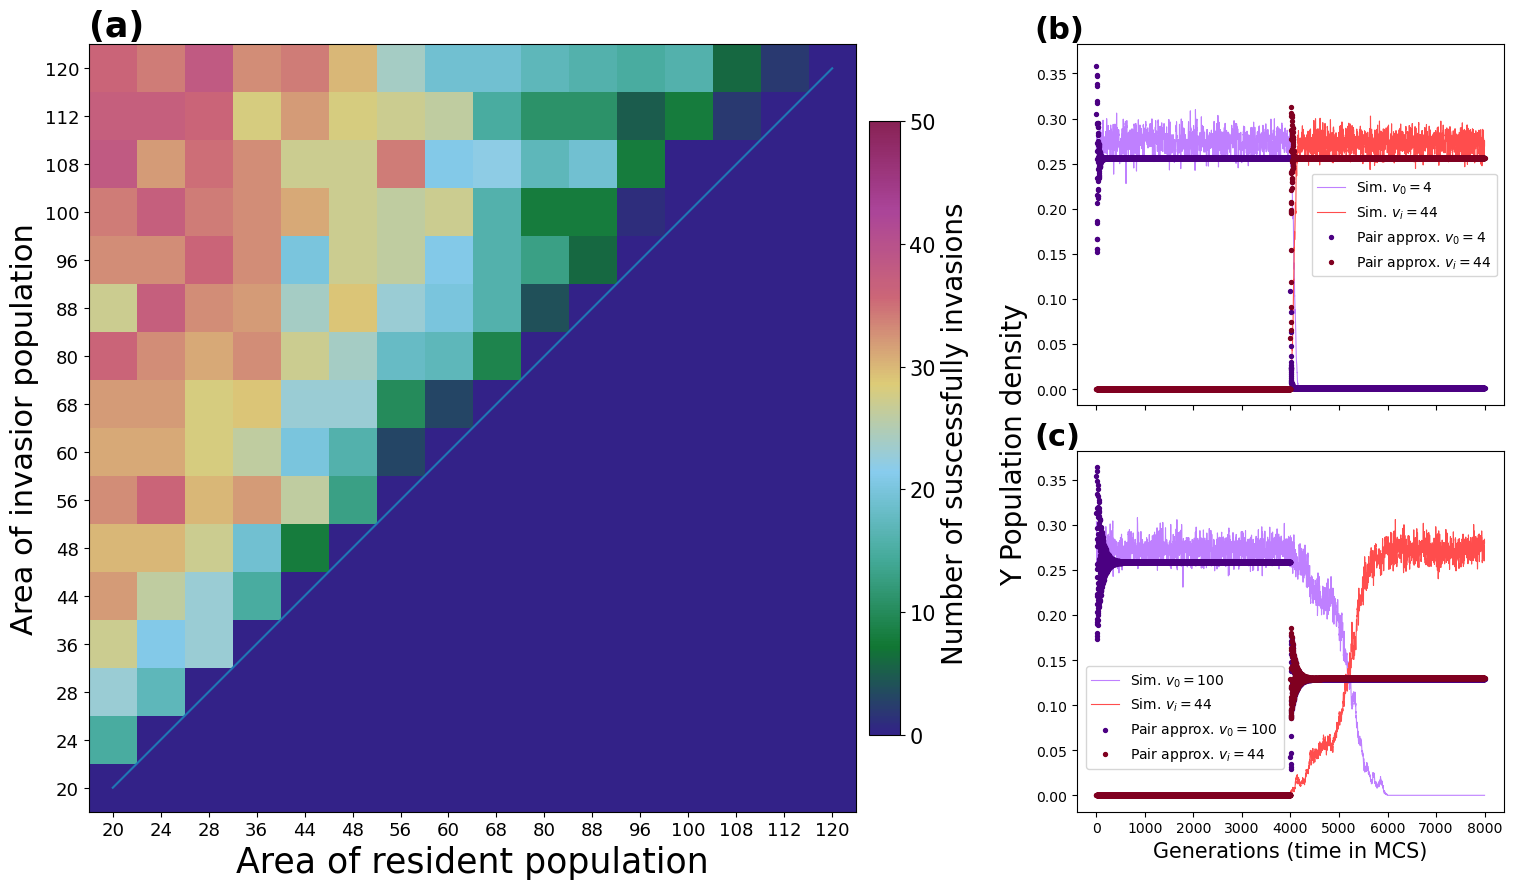

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Configuração da figura e grid (1 linha para (a), dividida em colunas)
fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[3.0, 1], height_ratios=[1, 1])

# -------------------------------------------------------------
# (a) Mapa de Calor (Heatmap) à esquerda (ocupando 2 linhas na vertical)
# -------------------------------------------------------------
ax_a = fig.add_subplot(gs[:, 0])
paleta = ['#332288','#117733','#44AA99','#88CCEE','#DDCC77','#CC6677','#AA4499','#882255']
cmap = LinearSegmentedColormap.from_list("minha_paleta", paleta)
im = ax_a.imshow(contagem, cmap=cmap, origin='lower', vmin=0, vmax=50)
cbar = fig.colorbar(im, ax=ax_a, shrink=0.8, pad = 0.01)
cbar.ax.tick_params(labelsize=15) 
ax_a.set_xticks(np.arange(len(raios)))
ax_a.set_xticklabels(raios)
ax_a.set_yticks(np.arange(len(raios)))
ax_a.set_yticklabels(raios)
cbar.set_label(r"Number of suscessfully invasions ", fontsize=20)
ax_a.plot(np.linspace(0,len(raios)-1,len(raios)-1), np.linspace(0,len(raios)-1,len(raios)-1))
ax_a.set_xlabel("Area of resident population", fontsize = 25)
ax_a.set_ylabel("Area of invasior population", fontsize = 22)
ax_a.set_title("(a)", loc='left',fontweight='bold',fontsize = 25)
ax_a.tick_params(axis='both', labelsize=13)
'''
ax_a.axvspan(
    xmin=-0.5, xmax=18.5, 
    ymin=38/120, ymax=57/120, 
    facecolor='none', edgecolor='#B978E0', linewidth=2.5, zorder=5
)

ax_a.axvspan(
    xmin=5.5, xmax=8.5, 
    ymin=0/160, ymax=160/160, 
    facecolor='none', edgecolor='#B978E0', linewidth=2.5, zorder=5
)
'''
# -------------------------------------------------------------
# (b) Gráfico de Série Temporal superior direito
# -------------------------------------------------------------
raio_inicial = 4
raio_invasor = 44
raios = [20,24,28,36,44,48,56,60,68,80,88,96,100,108,112,120]
vizY = [raio_inicial,raio_inicial]
hy = [1.2/vizY[0],1.2/vizY[1]]
vizZ = [12,12]
hz = [1.0/vizZ[0],1.0/vizZ[1]]
zera_medidas()
condicao_inicial()
Dinamica_pares(t, raio_invasor)
ax_b = fig.add_subplot(gs[0, 1])

ax_b.plot(tempo, ri4, color='#bf80ff', linewidth=0.8, label=r'Sim. $v_0 = 4$')
ax_b.plot(tempo, rf44, color='#ff4d4d', linewidth=0.8, label=r'Sim. $v_i = 44$')
ax_b.scatter(np.linspace(0,t//2,t//2), 2*mediay1pares[:t//2], color='#4b0082', s=8, label=r'Pair approx. $v_0 = 4$', zorder =2)
ax_b.scatter(np.linspace(t//2,t,t//2), mediay1pares[t//2:], color='#4b0082',s = 8, zorder =2)
ax_b.scatter(np.linspace(t//2,t,t//2), mediay2pares[4000:], color='#800020', s=8, label=r'Pair approx. $v_i = 44$', zorder =2)
ax_b.scatter(np.linspace(0,t//2,t//2), np.zeros(t//2), color='#800020', s=8, zorder =2)


ax_b.tick_params(labelbottom=False) # Remove o eixo x para colar no gráfico de baixo
ax_b.legend(fontsize=10, loc='center right')
ax_b.text(-0.1, 1.08, '(b)', transform=ax_b.transAxes, fontsize=22, fontweight='bold', va='top')


# -------------------------------------------------------------
# (c) Gráfico de Série Temporal inferior direito (Compartilhando o eixo Y com ax_b)
# -------------------------------------------------------------
raio_inicial = 100
raio_invasor = 44
raios = [20,24,28,36,44,48,56,60,68,80,88,96,100,108,112,120]
vizY = [raio_inicial,raio_inicial]
hy = [1.2/vizY[0],1.2/vizY[1]]
vizZ = [12,12]
hz = [1.0/vizZ[0],1.0/vizZ[1]]
zera_medidas()
condicao_inicial()
Dinamica_pares(t, raio_invasor)

# Adicionado sharey=ax_b para vincular os eixos Y
ax_c = fig.add_subplot(gs[1, 1], sharey=ax_b)

ax_c.plot(tempo, ri100,color='#bf80ff', linewidth=0.8, label=r'Sim. $v_0 = 100$')
ax_c.plot(tempo, rf44_2, color='#ff4d4d', linewidth=0.8, label=r'Sim. $v_i = 44$')
ax_c.scatter(np.linspace(0,t//2,t//2), 2*mediay1pares[:t//2],color='#4b0082', s=8, label=r'Pair approx. $v_0 = 100$', zorder =2)
ax_c.scatter(np.linspace(t//2,t,t//2), mediay1pares[t//2:],color='#4b0082', s=8, zorder =2)
ax_c.scatter(np.linspace(t//2,t,t//2), mediay2pares[4000:], color='#800020', s=8, label=r'Pair approx. $v_i = 44$', zorder =2)
ax_c.scatter(np.linspace(0,t//2,t//2), np.zeros(t//2), color='#800020', s=8, zorder =2)

ax_c.set_xlabel('Generations (time in MCS)', fontsize=15)
fig.supylabel('Y Population density', fontsize=20, x = 0.71)
ax_c.legend(fontsize=10, bbox_to_anchor = (0.5,0.1))
ax_c.text(-0.1, 1.08, '(c)', transform=ax_c.transAxes, fontsize=22, fontweight='bold', va='top')

# Se preferir esconder o texto/números do eixo Y duplicados em (c), descomente a linha abaixo:
# ax_c.tick_params(labelleft=False)
plt.tight_layout()
#plt.savefig("invasao-teste.pdf", bbox_inches = "tight")
plt.show()